# Plot posteriors of all case studies

In [1]:
# Load packages
import numpy as np # The 'numpy' package is needed for matrix operations and calculations
import pandas as pd # The 'pandas' package helps us to import and manage data
import matplotlib.pyplot as plt # The 'matplotlib' package contains tools needed to plot our data and results
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle # The 'Rectangle' function is used to add rectangles to our plots

### Load default DA outcomes of all case studies

In [2]:
Modern_priors_outcomes_df = pd.read_csv("Modern case/Modern_priors_outcomes.csv")
print(Modern_priors_outcomes_df.head())
PWP_priors_outcomes_df = pd.read_csv("PWP case/PWP_priors_outcomes.csv")
print(PWP_priors_outcomes_df.head())
Lutetian_priors_outcomes_df = pd.read_csv("Lutetian case/Lutetian_priors_outcomes.csv")
print(Lutetian_priors_outcomes_df.head())
Campanian_priors_outcomes_df = pd.read_csv("Campanian case/Campanian_priors_outcomes.csv")
print(Campanian_priors_outcomes_df.head())

   Unnamed: 0  mu_measurement_SST  std_measurement_SST  mu_measurement_SAT  \
0           0           26.053977             0.854203           27.213333   
1           1           22.937678             1.066253           27.093333   
2           2           22.177052             2.008748           27.160000   
3           3           25.165710             1.494855           27.400000   
4           4           27.723035             0.614689           27.653333   

   std_measurement_SAT  mu_measurement_SSS  std_measurement_SSS  \
0             0.547549           33.867704             2.134647   
1             0.460538           34.753169             1.416685   
2             0.523450           35.112823             1.121933   
3             0.484031           35.192466             1.020120   
4             0.354293           34.784739             1.314595   

   mu_measurement_precip  std_measurement_precip  mu_prior_SST  ...  \
0               0.831935                1.103908     27.4

# Plot monthly priors, likelihoods and posteriors for all cases together

## Define function that wraps the 12-month arrays into continuous seasonal plots

In [3]:
def wrap_monthly(arr):
    """Pad a 12-length monthly array with Dec at the start and Jan at the end,
    so plotted lines/CIs run to the axis margins instead of stopping at Jan/Dec."""
    arr = np.asarray(arr)
    edge = (arr[0] + arr[-1]) / 2  # mean of Jan and Dec
    return np.concatenate([[edge], arr, [edge]])

## Define wrapper function for plotting to avoid repetition

In [6]:
def plot_wrapped(ax, mean, sd, color, label,
                 alpha_line=1.0,
                 alpha_fill=0.2):
    """
    Plot mean +/- 2 SD using wrapped monthly data.
    """

    mean = np.asarray(mean)
    sd = np.asarray(sd)

    ax.plot(
        months_scale_ext,
        wrap_monthly(mean),
        color=color,
        marker='o',
        label=label,
        alpha=alpha_line
    )

    ax.fill_between(
        months_scale_ext,
        wrap_monthly(mean - 2 * sd),
        wrap_monthly(mean + 2 * sd),
        color=color,
        alpha=alpha_fill
    )

## Plot the priors, likelihoods and posteriors

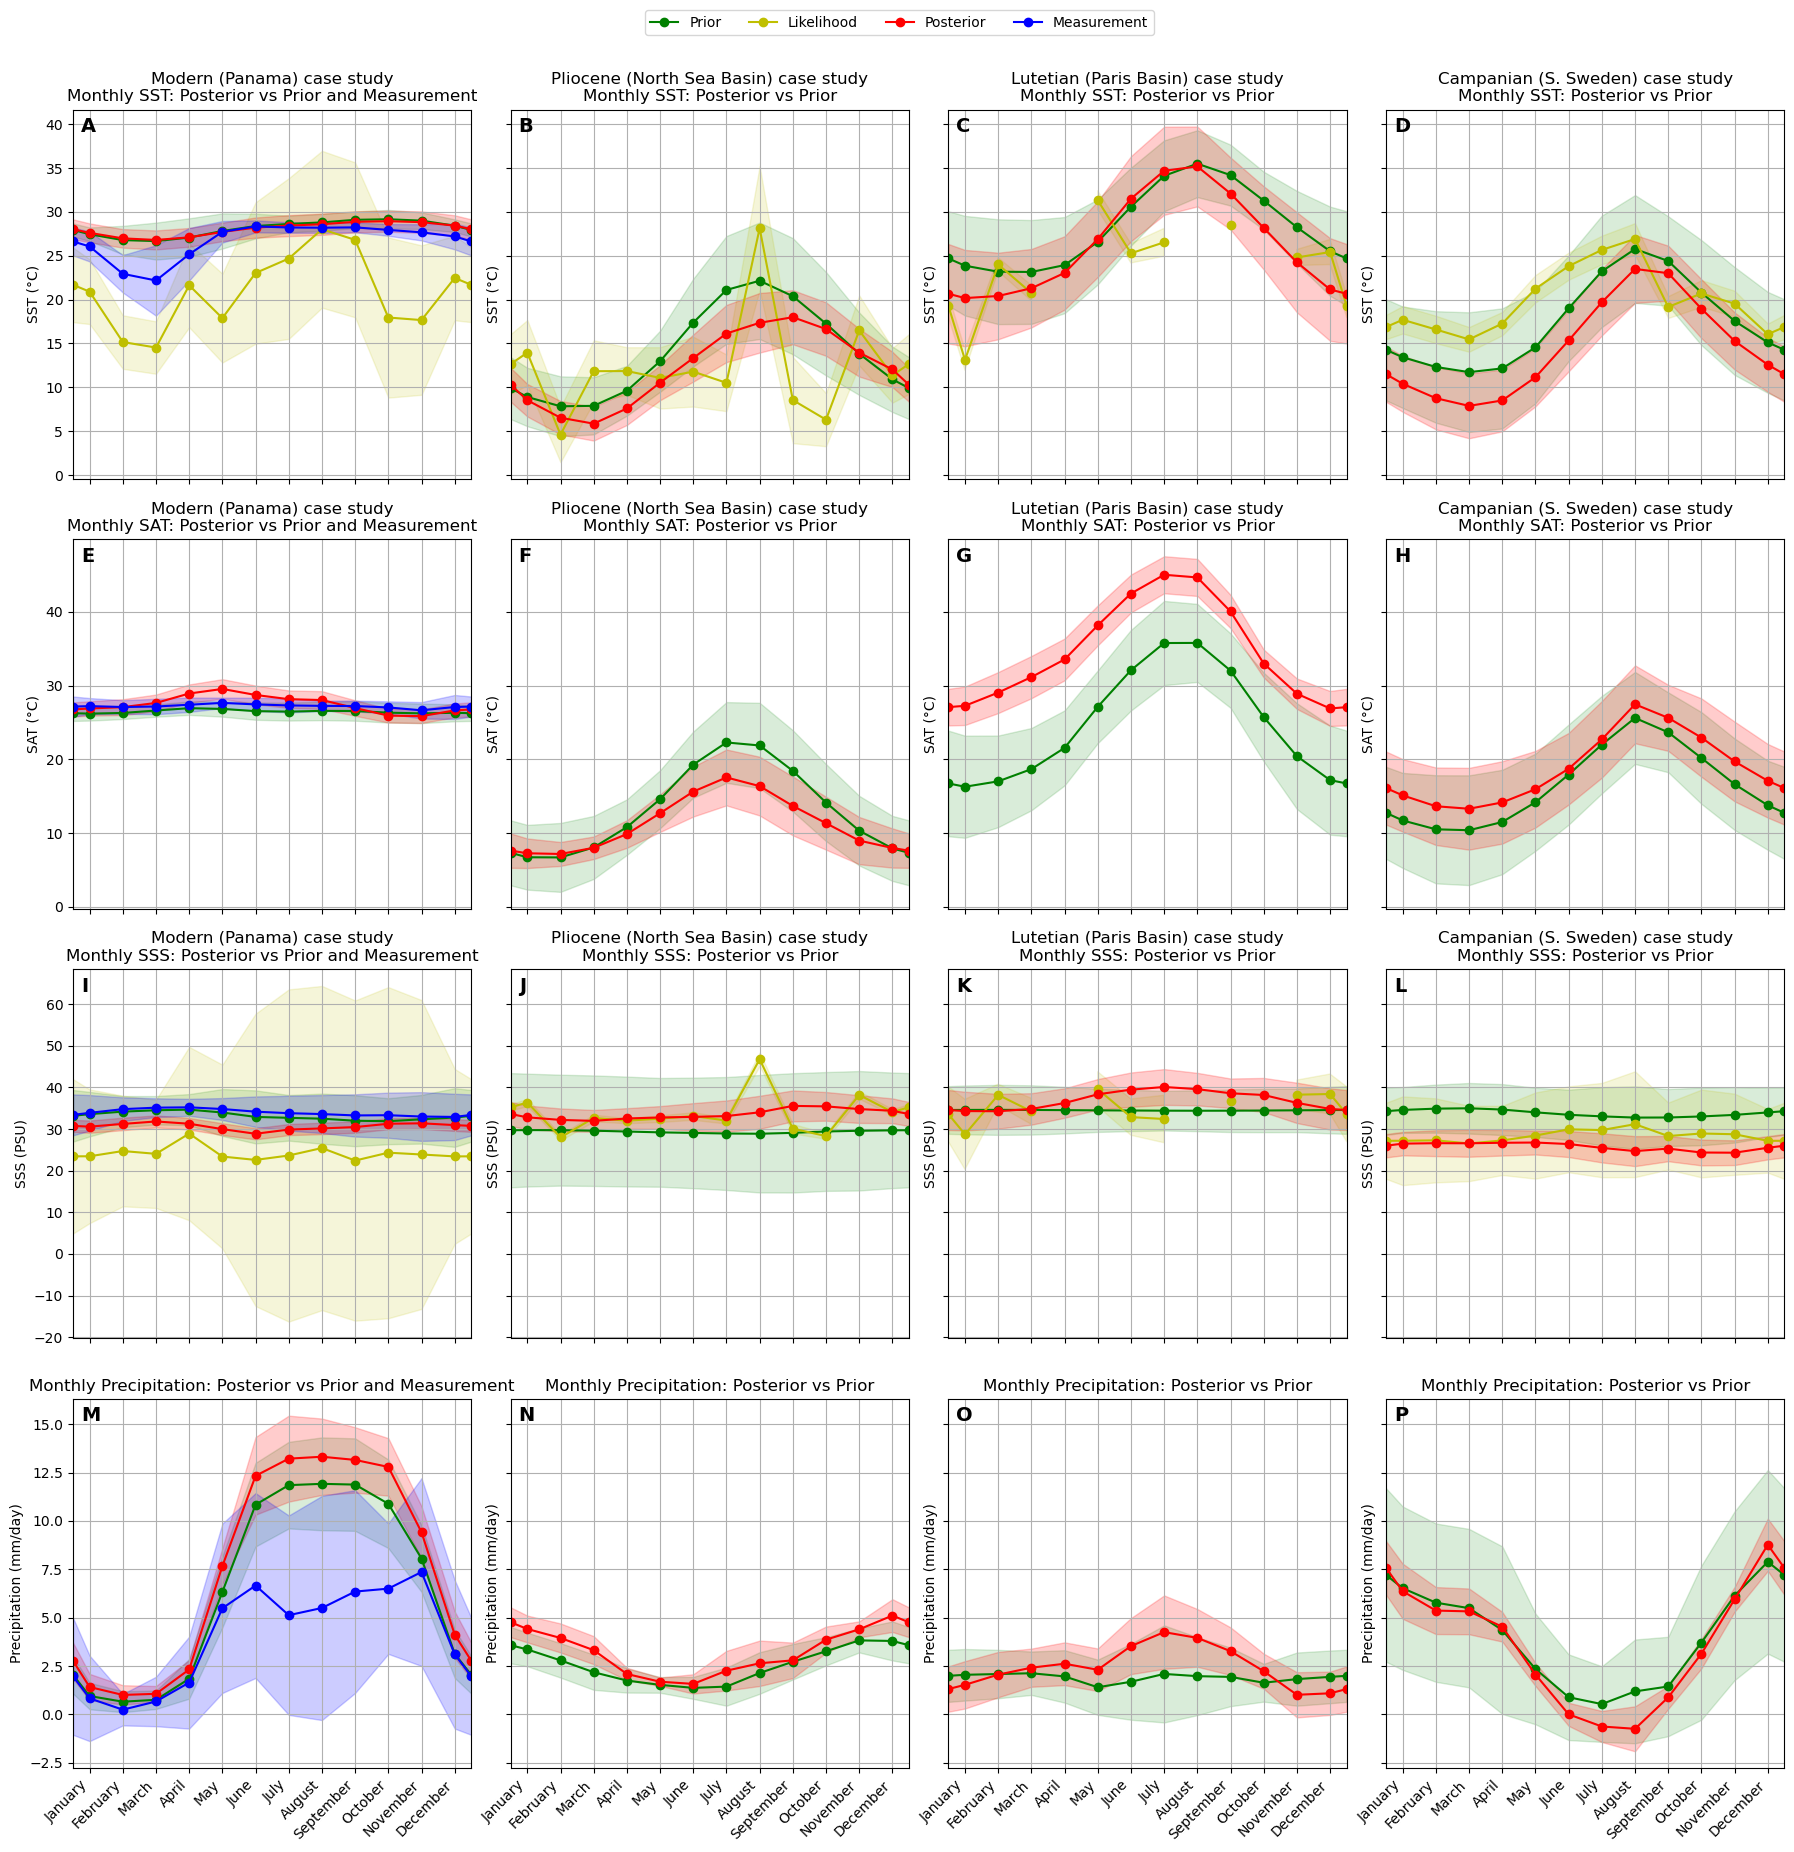

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(18, 18), sharex='col', sharey='row')
subplot_labels = list("ABCDEFGHIJKLMNOP")
for ax, label in zip(axes.flatten(), subplot_labels):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )

months_scale = np.arange(1, 13)
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
months_scale_ext = np.concatenate([[months_scale[0] - 0.5], months_scale, [months_scale[-1] + 0.5]])  # Create monthly scale extended to before and after January and December

# -------------------------
# Modern case study
# Panel 1: SST
# -------------------------

plot_wrapped(
    axes[0, 0],
    Modern_priors_outcomes_df['mu_prior_SST'],
    Modern_priors_outcomes_df['std_prior_SST'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 0],
    Modern_priors_outcomes_df['mu_likelihood_SST'],
    Modern_priors_outcomes_df['std_likelihood_SST'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 0],
    Modern_priors_outcomes_df['mu_post_SST'],
    Modern_priors_outcomes_df['std_post_SST'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

plot_wrapped(
    axes[0, 0],
    Modern_priors_outcomes_df['mu_measurement_SST'],
    Modern_priors_outcomes_df['std_measurement_SST'],
    'b',
    'Measurement',
    alpha_fill=0.20
)

axes[0, 0].set_ylabel('SST (°C)')
axes[0, 0].set_title('Modern (Panama) case study\nMonthly SST: Posterior vs Prior and Measurement')
axes[0, 0].grid(True)

# -------------------------
# Modern case study
# Panel 2: SAT
# -------------------------

plot_wrapped(
    axes[1, 0],
    Modern_priors_outcomes_df['mu_prior_SAT'],
    Modern_priors_outcomes_df['std_prior_SAT'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[1, 0],
    Modern_priors_outcomes_df['mu_post_SAT'],
    Modern_priors_outcomes_df['std_post_SAT'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

plot_wrapped(
    axes[1, 0],
    Modern_priors_outcomes_df['mu_measurement_SAT'],
    Modern_priors_outcomes_df['std_measurement_SAT'],
    'b',
    'Measurement',
    alpha_fill=0.20
)

axes[1, 0].set_ylabel('SAT (°C)')
axes[1, 0].set_title('Modern (Panama) case study\nMonthly SAT: Posterior vs Prior and Measurement')
axes[1, 0].grid(True)

# -------------------------
# Modern case study
# Panel 3: SSS
# -------------------------

plot_wrapped(
    axes[2, 0],
    Modern_priors_outcomes_df['mu_prior_SSS'],
    Modern_priors_outcomes_df['std_prior_SSS'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 0],
    Modern_priors_outcomes_df['mu_likelihood_SSS'],
    Modern_priors_outcomes_df['std_likelihood_SSS'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 0],
    Modern_priors_outcomes_df['mu_post_SSS'],
    Modern_priors_outcomes_df['std_post_SSS'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

plot_wrapped(
    axes[2, 0],
    Modern_priors_outcomes_df['mu_measurement_SSS'],
    Modern_priors_outcomes_df['std_measurement_SSS'],
    'b',
    'Measurement',
    alpha_fill=0.20
)

axes[2, 0].set_ylabel('SSS (PSU)')
axes[2, 0].set_title('Modern (Panama) case study\nMonthly SSS: Posterior vs Prior and Measurement')
axes[2, 0].grid(True)

# -------------------------
# Modern case study
# Panel 4: Precipitation
# -------------------------

plot_wrapped(
    axes[3, 0],
    Modern_priors_outcomes_df['mu_prior_precip'],
    Modern_priors_outcomes_df['std_prior_precip'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[3, 0],
    Modern_priors_outcomes_df['mu_post_precip'],
    Modern_priors_outcomes_df['cov_post_precip'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

plot_wrapped(
    axes[3, 0],
    Modern_priors_outcomes_df['mu_measurement_precip'],
    Modern_priors_outcomes_df['std_measurement_precip'],
    'b',
    'Measurement',
    alpha_fill=0.20
)

axes[3, 0].set_ylabel('Precipitation (mm/day)')
axes[3, 0].set_title('Monthly Precipitation: Posterior vs Prior and Measurement')
axes[3, 0].grid(True)

# -------------------------
# Pliocene case study
# Panel 1: SST
# -------------------------

plot_wrapped(
    axes[0, 1],
    PWP_priors_outcomes_df['mu_prior_SST'],
    PWP_priors_outcomes_df['std_prior_SST'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 1],
    PWP_priors_outcomes_df['mu_likelihood_SST'],
    PWP_priors_outcomes_df['std_likelihood_SST'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 1],
    PWP_priors_outcomes_df['mu_post_SST'],
    PWP_priors_outcomes_df['std_post_SST'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[0, 1].set_ylabel('SST (°C)')
axes[0, 1].set_title('Pliocene (North Sea Basin) case study\nMonthly SST: Posterior vs Prior')
axes[0, 1].grid(True)

# -------------------------
# Pliocene case study
# Panel 2: SAT
# -------------------------

plot_wrapped(
    axes[1, 1],
    PWP_priors_outcomes_df['mu_prior_SAT'],
    PWP_priors_outcomes_df['std_prior_SAT'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[1, 1],
    PWP_priors_outcomes_df['mu_post_SAT'],
    PWP_priors_outcomes_df['std_post_SAT'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[1, 1].set_ylabel('SAT (°C)')
axes[1, 1].set_title('Pliocene (North Sea Basin) case study\nMonthly SAT: Posterior vs Prior')
axes[1, 1].grid(True)

# -------------------------
# Pliocene case study
# Panel 3: SSS
# -------------------------

plot_wrapped(
    axes[2, 1],
    PWP_priors_outcomes_df['mu_prior_SSS'],
    PWP_priors_outcomes_df['std_prior_SSS'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 1],
    PWP_priors_outcomes_df['mu_likelihood_SSS'],
    PWP_priors_outcomes_df['std_likelihood_SSS'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 1],
    PWP_priors_outcomes_df['mu_post_SSS'],
    PWP_priors_outcomes_df['std_post_SSS'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[2, 1].set_ylabel('SSS (PSU)')
axes[2, 1].set_title('Pliocene (North Sea Basin) case study\nMonthly SSS: Posterior vs Prior')
axes[2, 1].grid(True)

# -------------------------
# Pliocene case study
# Panel 4: Precipitation
# -------------------------

plot_wrapped(
    axes[3, 1],
    PWP_priors_outcomes_df['mu_prior_precip'],
    PWP_priors_outcomes_df['std_prior_precip'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[3, 1],
    PWP_priors_outcomes_df['mu_post_precip'],
    PWP_priors_outcomes_df['cov_post_precip'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[3, 1].set_ylabel('Precipitation (mm/day)')
axes[3, 1].set_title('Monthly Precipitation: Posterior vs Prior')
axes[3, 1].grid(True)

# -------------------------
# Lutetian case study
# Panel 1: SST
# -------------------------

plot_wrapped(
    axes[0, 2],
    Lutetian_priors_outcomes_df['mu_prior_SST'],
    Lutetian_priors_outcomes_df['std_prior_SST'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 2],
    Lutetian_priors_outcomes_df['mu_likelihood_SST'],
    Lutetian_priors_outcomes_df['std_likelihood_SST'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 2],
    Lutetian_priors_outcomes_df['mu_post_SST'],
    Lutetian_priors_outcomes_df['std_post_SST'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[0, 2].set_ylabel('SST (°C)')
axes[0, 2].set_title('Lutetian (Paris Basin) case study\nMonthly SST: Posterior vs Prior')
axes[0, 2].grid(True)

# -------------------------
# Lutetian case study
# Panel 2: SAT
# -------------------------

plot_wrapped(
    axes[1, 2],
    Lutetian_priors_outcomes_df['mu_prior_SAT'],
    Lutetian_priors_outcomes_df['std_prior_SAT'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[1, 2],
    Lutetian_priors_outcomes_df['mu_post_SAT'],
    Lutetian_priors_outcomes_df['std_post_SAT'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[1, 2].set_ylabel('SAT (°C)')
axes[1, 2].set_title('Lutetian (Paris Basin) case study\nMonthly SAT: Posterior vs Prior')
axes[1, 2].grid(True)

# -------------------------
# Lutetian case study
# Panel 3: SSS
# -------------------------

plot_wrapped(
    axes[2, 2],
    Lutetian_priors_outcomes_df['mu_prior_SSS'],
    Lutetian_priors_outcomes_df['std_prior_SSS'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 2],
    Lutetian_priors_outcomes_df['mu_likelihood_SSS'],
    Lutetian_priors_outcomes_df['std_likelihood_SSS'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 2],
    Lutetian_priors_outcomes_df['mu_post_SSS'],
    Lutetian_priors_outcomes_df['std_post_SSS'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[2, 2].set_ylabel('SSS (PSU)')
axes[2, 2].set_title('Lutetian (Paris Basin) case study\nMonthly SSS: Posterior vs Prior')
axes[2, 2].grid(True)

# -------------------------
# Lutetian case study
# Panel 4: Precipitation
# -------------------------

plot_wrapped(
    axes[3, 2],
    Lutetian_priors_outcomes_df['mu_prior_precip'],
    Lutetian_priors_outcomes_df['std_prior_precip'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[3, 2],
    Lutetian_priors_outcomes_df['mu_post_precip'],
    Lutetian_priors_outcomes_df['cov_post_precip'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[3, 2].set_ylabel('Precipitation (mm/day)')
axes[3, 2].set_title('Monthly Precipitation: Posterior vs Prior')
axes[3, 2].grid(True)

# -------------------------
# Campanian case study
# Panel 1: SST
# -------------------------

plot_wrapped(
    axes[0, 3],
    Campanian_priors_outcomes_df['mu_prior_SST'],
    Campanian_priors_outcomes_df['std_prior_SST'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 3],
    Campanian_priors_outcomes_df['mu_likelihood_SST'],
    Campanian_priors_outcomes_df['std_likelihood_SST'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[0, 3],
    Campanian_priors_outcomes_df['mu_post_SST'],
    Campanian_priors_outcomes_df['std_post_SST'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[0, 3].set_ylabel('SST (°C)')
axes[0, 3].set_title('Campanian (S. Sweden) case study\nMonthly SST: Posterior vs Prior')
axes[0, 3].grid(True)

# -------------------------
# Campanian case study
# Panel 2: SAT
# -------------------------

plot_wrapped(
    axes[1, 3],
    Campanian_priors_outcomes_df['mu_prior_SAT'],
    Campanian_priors_outcomes_df['std_prior_SAT'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[1, 3],
    Campanian_priors_outcomes_df['mu_post_SAT'],
    Campanian_priors_outcomes_df['std_post_SAT'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[1, 3].set_ylabel('SAT (°C)')
axes[1, 3].set_title('Campanian (S. Sweden) case study\nMonthly SAT: Posterior vs Prior')
axes[1, 3].grid(True)

# -------------------------
# Campanian case study
# Panel 3: SSS
# -------------------------

plot_wrapped(
    axes[2, 3],
    Campanian_priors_outcomes_df['mu_prior_SSS'],
    Campanian_priors_outcomes_df['std_prior_SSS'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 3],
    Campanian_priors_outcomes_df['mu_likelihood_SSS'],
    Campanian_priors_outcomes_df['std_likelihood_SSS'],
    'y',
    'Likelihood',
    alpha_fill=0.15
)

plot_wrapped(
    axes[2, 3],
    Campanian_priors_outcomes_df['mu_post_SSS'],
    Campanian_priors_outcomes_df['std_post_SSS'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[2, 3].set_ylabel('SSS (PSU)')
axes[2, 3].set_title('Campanian (S. Sweden) case study\nMonthly SSS: Posterior vs Prior')
axes[2, 3].grid(True)

# -------------------------
# Campanian case study
# Panel 4: Precipitation
# -------------------------

plot_wrapped(
    axes[3, 3],
    Campanian_priors_outcomes_df['mu_prior_precip'],
    Campanian_priors_outcomes_df['std_prior_precip'],
    'g',
    'Prior',
    alpha_fill=0.15
)

plot_wrapped(
    axes[3, 3],
    Campanian_priors_outcomes_df['mu_post_precip'],
    Campanian_priors_outcomes_df['cov_post_precip'],
    'r',
    'Posterior',
    alpha_fill=0.20
)

axes[3, 3].set_ylabel('Precipitation (mm/day)')
axes[3, 3].set_title('Monthly Precipitation: Posterior vs Prior')
axes[3, 3].grid(True)

for ax in axes.flatten():
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(months_scale)
    ax.set_xticklabels(month_names, rotation=45, ha='right')

# Merge legends from all subplots into a single legend for the entire figure
legend_handles = []
legend_labels = []
for ax in axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label not in legend_labels:
            legend_handles.append(handle)
            legend_labels.append(label)
    legend = ax.get_legend()
    if legend:
        legend.remove()

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)
)
plt.tight_layout(rect=[0, 0, 1.5, 0.5])
plt.tight_layout()
plt.show()